In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
import os
import kagglehub
path = kagglehub.dataset_download("camnugent/california-housing-prices")
csv_path = os.path.join(path, "housing.csv")
df = pd.read_csv(csv_path)

In [3]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [6]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [7]:
## ocean proximitiy degerlerine bakicam icinde neler olup olmadigina

In [8]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [9]:
# ordinal encoding yapmaya cok uygun degil one hot encoding yapmayi daha uygun buluyorum 

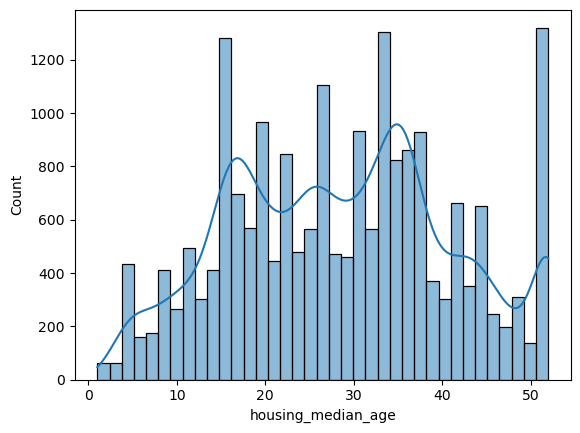

In [10]:
sns.histplot(data=df,x='housing_median_age',kde=True)
plt.show()

In [11]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

In [12]:
columns = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity']

for i ,  col in enumerate(columns):
    row = i // 3 
    col_idx = i % 3
    print(row,col_idx)

0 0
0 1
0 2
1 0
1 1
1 2
2 0
2 1
2 2
3 0


In [13]:
# Veri setindeki sütunları 3 sütunlu bir grafik matrisine (subplot grid) yerleştirmek için satır (i // 3) ve sütun (i % 3) indekslerini hesaplar.

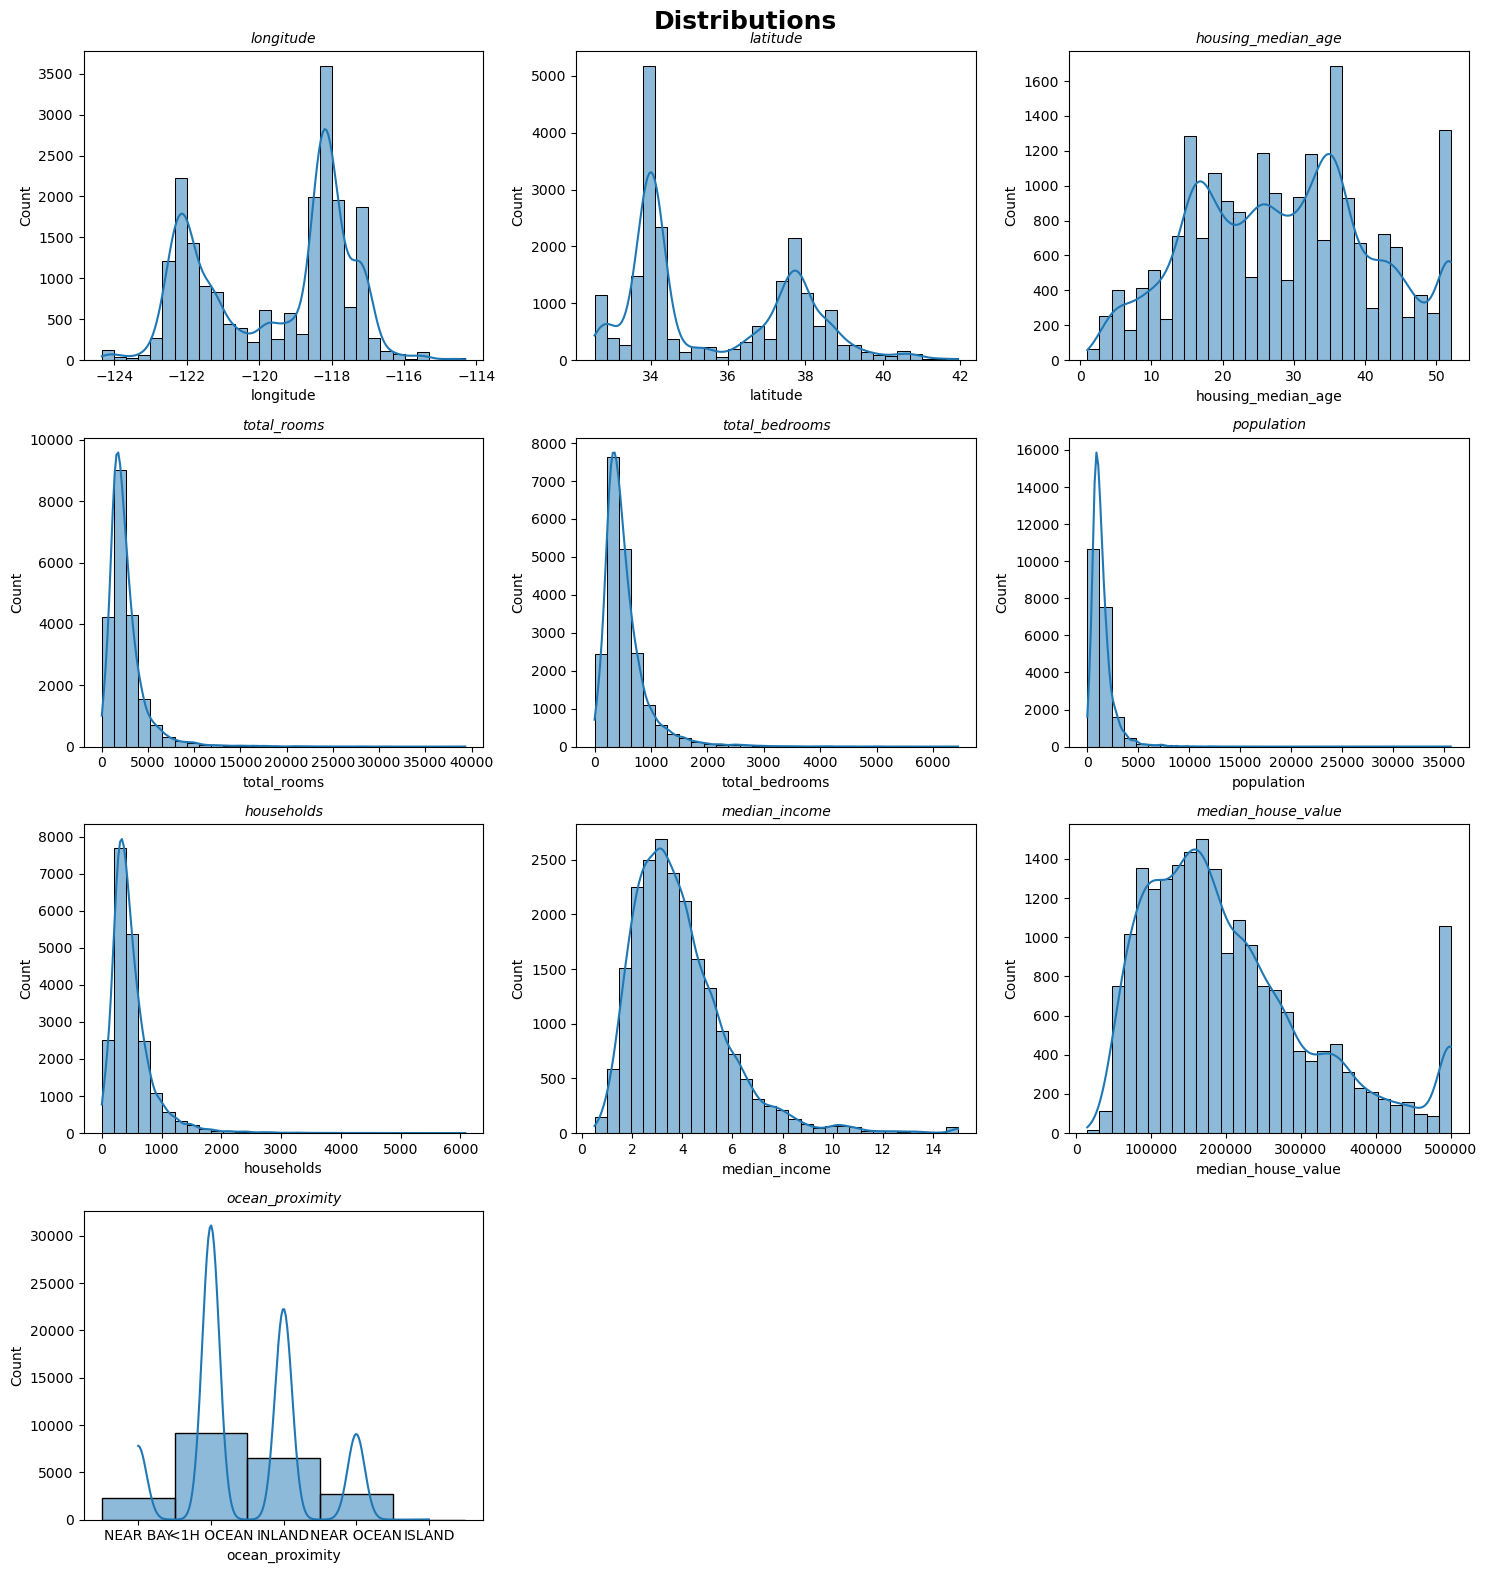

In [14]:
columns = [
    'longitude', 'latitude', 'housing_median_age', 'total_rooms',
    'total_bedrooms', 'population', 'households', 'median_income',
    'median_house_value', 'ocean_proximity'
]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 16))
fig.suptitle('Distributions', fontsize=18, fontweight='bold')

for i, col in enumerate(columns):
    row = i // 3
    col_idx = i % 3
    ax = axes[row, col_idx]
    sns.histplot(data=df, x=col, kde=True, ax=ax, bins=30)
    ax.set_title(col, fontsize=10, fontstyle='italic')

# Boş kalan 2 kutucuğu gizle
for j in range(len(columns), 4 * 3):
    fig.delaxes(axes[j // 3, j % 3])

plt.tight_layout()
plt.show()

In [15]:
# bins bize grafikteki cubuk sayisini veriyor 

In [16]:
df.corr(numeric_only=True) # sadece sayisal verileri goz ardi edecegi icin bunu yazariz 1 tane kategorik oldugu icin hata vermesini istemyiz kodumuzun

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [17]:
# verimizle alakali outliers lari bulmak istiyorum bunuj icin yapay zekadan yardim aliyorum/

In [18]:
def find_outliers_iqr(df):
    outlier_summary = {}

    numeric_cols = df.select_dtypes(include=['float64','int64']).columns
    print(numeric_cols)

In [19]:
find_outliers_iqr(df)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')


In [20]:
def find_outliers_iqr(df, threshold=1.5):
    outlier_summary = {}

    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    print(numeric_cols)
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        print(len(outliers))       

In [21]:
find_outliers_iqr(df)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')
0
0
0
1287
1271
1196
1220
681
1071


In [22]:
# Veri setindeki sayısal sütunlar için IQR (Çeyrekler Arası Genişlik) yöntemiyle alt ve üst sınırları belirleyerek aykırı değerleri (outliers)
# tespit eder ve sayısını yazdırır.

In [23]:
find_outliers_iqr(df,threshold=3) # threshold bizim  tahamul seviyemizi gosterir buna gore sonuclar elde ederiz 

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value'],
      dtype='object')
0
0
0
494
443
421
415
140
0


In [24]:
def find_outliers_iqr(df, threshold=1.5):
    outlier_summary = {}

    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        
        outlier_summary[col] = {
            "outlier_count": outliers.shape[0],
            "outlier_percentage": 100 * outliers.shape[0] / df.shape[0],
            "lower_bound": lower_bound,
            "upper_bound": upper_bound
        }

    return pd.DataFrame(outlier_summary)

In [25]:
find_outliers_iqr(df,threshold=1.5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
outlier_count,0.000,0.00,0.0,1287.000000,1271.000000,1196.000000,1220.000000,681.000000,1071.000000
outlier_percentage,0.000,0.00,0.0,6.235465,6.157946,5.794574,5.910853,3.299419,5.188953
lower_bound,-127.485,28.26,-10.5,-1102.625000,-230.500000,-620.000000,-207.500000,-0.706375,-98087.500000
upper_bound,-112.325,43.38,65.5,5698.375000,1173.500000,3132.000000,1092.500000,8.013025,482412.500000


In [26]:
# ÇIKARIMLAR:
# 1. Coğrafi konum (lat/long) ve bina yaşında aykırı değer bulunmamaktadır (%0).
# 2. Bölge büyüklüğünü belirten hacimsel değişkenlerde (total_rooms, total_bedrooms, population, households) %6'ya yakın yüksek oranda aykırı değer mevcuttur; bu durum büyük yerleşim bloklarına işaret eder.
# 3. Ev değerleri ve gelir düzeyinde %3-%5 bandında sağa çarpık (sağ tarafta uç değerler barındıran) bir aykırı değer dağılımı görülmektedir.

In [27]:
# verimizde median house value kismini outlier edecegim cunku amacimiz ev fiyatlkari oldugu icin vermi en cok bu bozuyor 

In [28]:
#  GENEL İLKE:
# 1. 'median_house_value' hedef değişken (target) olduğu için uç değerler modeli ve hatayı (RMSE) doğrudan bozar; bu yüzden müdahale edilir.
# 2. Girdi değişkenlerindeki (total_rooms, population vb.) aykırı değerler veri hatası değil, büyük yapılara ait gerçek bilgidir; silinirse bilgi kaybı olur.
# 3. İleride karar verirken: Hedef değişkendeki uçlar temizlenir/baskılanır; girdi değişkenlerindeki uçlara ise kullanılan modele göre (Ağaç modellerinde dokunulmaz, Çizgisel modellerde düzenlenir) karar verilir.

In [29]:
def remove_outliers_from_column(df, col, threshold=1.5):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    return df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

In [30]:
# MANTIĞI:
# Belirtilen tek bir sütun için IQR yöntemiyle alt ve üst sınırları hesaplar;
# sadece bu sınırlar içinde kalan (aykırı olmayan) gözlemleri filtreleyip yeni DataFrame'i döndürür.

In [31]:
def remove_outliers_from_all_columns(df, threshold=1.5):
    df_clean = df.copy()
    numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        df_clean = df_clean[(df_clean[col] >= lower_bound) & (df_clean[col] <= upper_bound)]

    return df_clean.copy()

In [32]:
# MANTIĞI:
# Veri setindeki tüm sayısal sütunları sırayla gezer; her bir sütundaki aykırı değerleri
# kademeli olarak veri setinden siler ve en son tamamen temizlenmiş DataFrame'i döndürür.

In [33]:
print("original data shape: ", df.shape)
df_target_clean = remove_outliers_from_column(df, "median_house_value")
print("only target column cleaning shape: ", df_target_clean.shape)
df_all_clean = remove_outliers_from_all_columns(df)
print("all columns cleaning shape: ", df_all_clean.shape)

original data shape:  (20640, 10)
only target column cleaning shape:  (19569, 10)
all columns cleaning shape:  (17446, 10)


In [34]:
df_target_clean.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        200
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [35]:
df_target_clean.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19569.000000,19569.000000,19569.000000,19569.000000,19369.000000,19569.000000,19569.000000,19569.000000,19569.000000
mean,-119.562786,35.654159,28.352752,2619.977260,539.893335,1442.788952,501.394859,3.665568,190852.301906
std,2.005764,2.151007,12.497772,2183.419302,422.650225,1145.011369,383.396308,1.557927,95438.555669
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.760000,33.930000,18.000000,1438.000000,297.000000,797.000000,282.000000,2.522700,116200.000000
50%,-118.510000,34.270000,28.000000,2110.000000,437.000000,1181.000000,411.000000,3.441200,173200.000000
75%,-117.990000,37.730000,37.000000,3123.000000,648.000000,1749.000000,606.000000,4.572100,246700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,482200.000000


In [36]:
# 1. Sütunu sayısal veriye çevir (dönüştürülemeyen değerler varsa NaN yapar)
df_target_clean['total_bedrooms'] = pd.to_numeric(df_target_clean['total_bedrooms'], errors='coerce')

# 2. Eksik (NaN) değerleri medyan ile doldur
df_target_clean['total_bedrooms'] = df_target_clean['total_bedrooms'].fillna(df_target_clean['total_bedrooms'].median())

C:\Users\PC\AppData\Local\Temp\ipykernel_13684\1743604520.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_target_clean['total_bedrooms'] = pd.to_numeric(df_target_clean['total_bedrooms'], errors='coerce')
C:\Users\PC\AppData\Local\Temp\ipykernel_13684\1743604520.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_target_clean['total_bedrooms'] = df_target_clean['total_bedrooms'].fillna(df_target_clean['total_bedrooms'].median())


In [37]:
df_target_clean.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000,19569.000000
mean,-119.562786,35.654159,28.352752,2619.977260,538.841739,1442.788952,501.394859,3.665568,190852.301906
std,2.005764,2.151007,12.497772,2183.419302,420.612109,1145.011369,383.396308,1.557927,95438.555669
min,-124.350000,32.540000,1.000000,2.000000,2.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.760000,33.930000,18.000000,1438.000000,299.000000,797.000000,282.000000,2.522700,116200.000000
50%,-118.510000,34.270000,28.000000,2110.000000,437.000000,1181.000000,411.000000,3.441200,173200.000000
75%,-117.990000,37.730000,37.000000,3123.000000,645.000000,1749.000000,606.000000,4.572100,246700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,482200.000000


In [38]:
df_target_clean.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [39]:
df_target_clean['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     8552
INLAND        6519
NEAR OCEAN    2419
NEAR BAY      2074
ISLAND           5
Name: count, dtype: int64

In [40]:
df_target_clean = pd.get_dummies(df_target_clean,columns =['ocean_proximity'],drop_first=True )

In [41]:
df_target_clean.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


In [42]:
# GET DUMMIES:
# 'ocean_proximity' kategorik sütununu One-Hot Encoding ile 0 ve 1 sayısal sütunlarına dönüştürür;
# 'drop_first=True' parametresi ile çoklu doğrusallık (Dummy Variable Trap) sorununu önlemek için ilk kategoriyi düşürür.

In [43]:
X = df_target_clean.drop('median_house_value',axis = 1)
y = df_target_clean['median_house_value']

In [44]:
from sklearn.model_selection import train_test_split

In [45]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=15)

In [46]:
X_train.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'ocean_proximity_INLAND', 'ocean_proximity_ISLAND',
       'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN'],
      dtype='object')

In [47]:
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor,GradientBoostingRegressor
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error,mean_squared_error

In [48]:
# ==============================================================================
# 1. ÇİZGİSEL MODELLER (LINEAR MODELS)
# ==============================================================================

# LinearRegression:
# - Mantık: Bağımsız değişkenler ile target arasında doğrusal ilişki kurar.
# - Kullanım: Doğrusal ilişkilerde hızlı ve anlaşılır bir referans (baseline) model olarak tercih edilir.
# - Uyarı: Aykırı değerlere ve overfitting'e (aşırı öğrenme) karşı oldukça hassastır.

# Ridge:
# - Mantık: L2 Regülasyonu uygular; katsayıları sıfıra yaklaştırır fakat tamamen sıfırlamaz.
# - Kullanım: Değişkenler arasında yüksek korelasyon (çoklu doğrusallık) veya overfitting riski olduğunda kullanılır.

# Lasso:
# - Mantık: L1 Regülasyonu uygular; önemsiz değişkenlerin katsayılarını tamamen sıfır (0) yapar.
# - Kullanım: Çok sayıda değişken bulunan veri setlerinde otomatik özellik seçimi (feature selection) için kullanılır.


# ==============================================================================
# 2. AĞAÇ TABANLI MODELLER (TREE-BASED MODELS)
# ==============================================================================

# DecisionTreeRegressor:
# - Mantık: Veriyi mantıksal if-else kurallarıyla dallara ayırarak tahmin yapar.
# - Kullanım: Hızlı, kolay görselleştirilebilir ve açıklanabilir bir yapı istendiğinde kullanılır.
# - Uyarı: Tek başına kurulduğunda veriyi ezberlemeye (overfitting) son derece meyillidir.


# ==============================================================================
# 3. TOPLULUK MODELLERİ (ENSEMBLE MODELS)
# ==============================================================================

# RandomForestRegressor (Bagging):
# - Mantık: Yüzlerce karar ağacını farklı veri alt kümelerinde bağımsız eğitip ortalamasını alır.
# - Kullanım: Overfitting'i engellemek, kararlı ve genel başarısı yüksek bir model elde etmek için idealdir.

# AdaBoostRegressor (Boosting):
# - Mantık: Sırayla ağaç kurar; her yeni ağaç bir önceki ağacın yaptığı hatalara odaklanır.
# - Kullanım: Zayıf tahmincilerin performansını kademeli olarak artırmak istendiğinde kullanılır.

# GradientBoostingRegressor (Boosting):
# - Mantık: Hataların gradyanını (artıkları) tahmin edecek şekilde ardışık ağaçlar inşa eder.
# - Kullanım: Karmaşık veri setlerinde yüksek tahmin başarısı elde etmek için standart bir güçlü seçenektir.

# XGBRegressor (Extreme Gradient Boosting):
# - Mantık: Gradient Boosting yapısının donanım olarak optimize edilmiş, regülasyonlu ve çok hızlı halidir.
# - Kullanım: Tabüler verilerde ve yarışmalarda en yüksek performansı almak için ilk sırada tercih edilir.


# ==============================================================================
# 4. KOMŞULUK TABANLI MODELLER (DISTANCE-BASED MODELS)
# ==============================================================================

# KNeighborsRegressor (KNN):
# - Mantık: Tahmin edilecek veri noktasına en yakın K adet komşunun değer ortalamasını alır.
# - Kullanım: Küçük ve orta ölçekli, coğrafi/konumsal ilişkisi yüksek verilerde kullanılır.
# - Uyarı: Verilerin ölçeklenmesi (StandardScaler vb.) şarttır; büyük veride yavaş çalışır.


# ==============================================================================
# 5. MODEL DEĞERLENDİRME METRİKLERİ (METRICS)
# ==============================================================================

# r2_score (R-Kare):
# - Bağımsız değişkenlerin, hedef değişkendeki değişimin yüzde kaçını açıklayabildiğini gösterir (1.0 mükemmeldir).

# mean_absolute_error (MAE):
# - Tahmin hatalarının mutlak ortalamasıdır. Gerçek birimle aynı ölçektedir ve aykırı değerlere karşı esnektir.

# mean_squared_error (MSE):
# - Hataların karesinin ortalamasıdır. Büyük hataları karesini alarak cezalandırdığı için aykırı değer hassasiyetini ölçer.

In [49]:
# yukarida kisa bir tekrar notu hazirladim  

In [50]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, rmse, r2_square

In [51]:
# MANTIĞI:
# Gerçek değerler (true) ile modelin tahmin ettiği değerleri (predicted) karşılaştırarak
# MAE, RMSE ve R2 skorlarını hesaplar ve bu başarım metriklerini geriye döndürür.

In [52]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "Adaboost Regressor": AdaBoostRegressor(),
    "Gradient Boost Regressor": GradientBoostingRegressor(),
    "XGBoost Regressor": XGBRegressor()
}

In [53]:
for i in range(len(list(models))):
    print(i)

0
1
2
3
4
5
6
7
8


In [54]:
# basliklarimiza kisaca bir index numarasi verdik isimiz daha koolay olsun diye 

In [55]:
# MANTIĞI:
# 'models' sözlüğündeki her modeli sırayla alır, eğitim verisiyle (X_train, y_train) eğitir.
# Ardından hem eğitim hem de test veri setleri üzerinde tahminler yaptırarak 'evaluate_model' 
# fonksiyonu yardımıyla RMSE, MAE ve R2 skorlarını hesaplar ve sonuçları ekrana yazdırır.

In [56]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    print("Model performance for Training Set")
    print("Root Mean Squared Error: ", model_train_rmse)
    print("Mean Absolute Error: ", model_train_mae)
    print("R2 Score: ", model_train_r2)

    print("----------------------------------")

    print("Model performance for Test Set")
    print("Root Mean Squared Error: ", model_test_rmse)
    print("Mean Absolute Error: ", model_test_mae)
    print("R2 Score: ", model_test_r2)

    print("----------------------------------")
    print("\n")

Linear Regression
Model performance for Training Set
Root Mean Squared Error:  59377.105929262376
Mean Absolute Error:  43858.387482410784
R2 Score:  0.6104236470924751
----------------------------------
Model performance for Test Set
Root Mean Squared Error:  58769.547257392325
Mean Absolute Error:  43594.363863007944
R2 Score:  0.62632961572295
----------------------------------


Lasso
Model performance for Training Set
Root Mean Squared Error:  59377.14466856273
Mean Absolute Error:  43859.00858534626
R2 Score:  0.6104231387510854
----------------------------------
Model performance for Test Set
Root Mean Squared Error:  58768.462304422465
Mean Absolute Error:  43594.66878006589
R2 Score:  0.6263434123598097
----------------------------------


Ridge
Model performance for Training Set
Root Mean Squared Error:  59381.16868007145
Mean Absolute Error:  43864.677314937195
R2 Score:  0.6103703334199277
----------------------------------
Model performance for Test Set
Root Mean Squared E

In [57]:
# YORUMLAMA MANTIĞI:
# 1. Overfitting Kontrolü: Train R2 çok yüksek, Test R2 düşükse model ezberlemiştir (overfitting).
# 2. Model Başarısı: Test setinde en yüksek R2 ve en düşük RMSE/MAE değerine sahip model seçilir.
# 3. Model Karşılaştırması: Ağaç tabanlı topluluk modelleri (XGBoost, Random Forest), karmaşık verilerde doğrusal modellere (Linear/Ridge) göre genelde daha yüksek performans gösterir.

In [58]:
# XGBOOST ICIN HYPERPARAMETRE TUNING 

In [59]:
sgboost_params = {
    'learning_rate':[0.1,0.01],
    'max_depth':[5,8,12,20,30],
    'n_estimators':[100,200,300,500],
    'colsample_bytree':[0.3,0.4,0.5,0.7,1]
}

In [60]:
from sklearn.model_selection import RandomizedSearchCV

In [61]:
randomized_cv = RandomizedSearchCV(estimator=XGBRegressor(),param_distributions=sgboost_params,cv = 5 ,n_jobs = -1 )

In [62]:
randomized_cv.fit(X_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=True,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints...
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.3, 0.4, 0.5, 0.7,
                                                             1],
                                        'learning_rate': [0.1, 0.01],
                                        'max_depth': [5, 8, 12, 20, 30],
                                        'n_estimators': [100, 200, 300, 500]})

In [63]:
randomized_cv.best_params_

{'n_estimators': 500,
 'max_depth': 8,
 'learning_rate': 0.1,
 'colsample_bytree': 0.7}

In [64]:
model = XGBRegressor(n_estimators = 300 , max_depth = 6 , learning_rate = 0.1 , colsample_bytree = 0.7)

In [65]:
# MAX_DEPTH DENGESİ:
# max_depth değerini 20 yerine 6 yapmak, ağacın aşırı derinleşmesini 
# ve veriyi ezberlemesini (overfitting) engelleyerek modelin genelleme yeteneğini korur.

In [66]:
model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [67]:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)
    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    print("Model performance for Training Set")
    print("Root Mean Squared Error: ", model_train_rmse)
    print("Mean Absolute Error: ", model_train_mae)
    print("R2 Score: ", model_train_r2)

    print("----------------------------------")

    print("Model performance for Test Set")
    print("Root Mean Squared Error: ", model_test_rmse)
    print("Mean Absolute Error: ", model_test_mae)
    print("R2 Score: ", model_test_r2)

    print("----------------------------------")
    print("\n")

XGBoost Regressor
Model performance for Training Set
Root Mean Squared Error:  24914.85615550394
Mean Absolute Error:  17694.89319608702
R2 Score:  0.9314083415292546
----------------------------------
Model performance for Test Set
Root Mean Squared Error:  41160.37108817686
Mean Absolute Error:  28022.115081677952
R2 Score:  0.8167084044906096
----------------------------------




In [68]:
# burada diger data setlerde kullanabilcegim bir suru kod var bunlari kullnamayi unutma 

In [69]:
from scipy.stats import skew

In [71]:
numeric_df = df.select_dtypes(include='number')

skewness = numeric_df.apply(skew).sort_values(ascending=False)

In [72]:
skewness

population            4.935500
total_rooms           4.147042
households            3.410190
median_income         1.646537
median_house_value    0.977692
latitude              0.465919
housing_median_age    0.060326
longitude            -0.297780
total_bedrooms             NaN
dtype: float64

In [81]:
y = df_target_clean['median_house_value']
X = df_target_clean.drop(columns=['median_house_value'])

In [82]:
from sklearn.model_selection import train_test_split

In [83]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=15)

In [84]:
from sklearn.preprocessing import  PowerTransformer

In [85]:
pt_X = PowerTransformer(method='yeo-johnson')

In [86]:
X_train_transformed = pt_X.fit_transform(X_train)
X_test_transformed = pt_X.transform(X_test)

In [87]:
X_train_transformed_df = pd.DataFrame(X_train_transformed,columns=X_train.columns)

In [88]:
X_train_transformed_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,1.387779e-15,-0.671009,0.486589,0.050535,0.024399,0.358262,0.058133,-0.018646,1.411199,-0.014801,-0.340747,-0.375912
1,2.470246e-15,-1.204064,-0.970340,0.432472,0.522800,0.628352,0.363502,-0.940026,-0.708617,-0.014801,-0.340747,-0.375912
2,2.053913e-15,-0.721618,0.022996,0.305957,0.685602,0.800713,0.621156,-0.907275,1.411199,-0.014801,-0.340747,-0.375912
3,1.471046e-15,-0.972146,-0.296774,0.225063,0.655914,0.434484,0.557085,-0.254036,-0.708617,-0.014801,-0.340747,-0.375912
4,-2.636780e-15,1.423100,-0.056065,-0.548070,-0.448934,-0.944478,-0.697868,-2.133232,1.411199,-0.014801,-0.340747,-0.375912


In [90]:
import math
def plot_all_histograms(df, title_prefix = ""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize = (5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel('')
        plt.ylabel('')

    plt.tight_layout()
    plt.show()

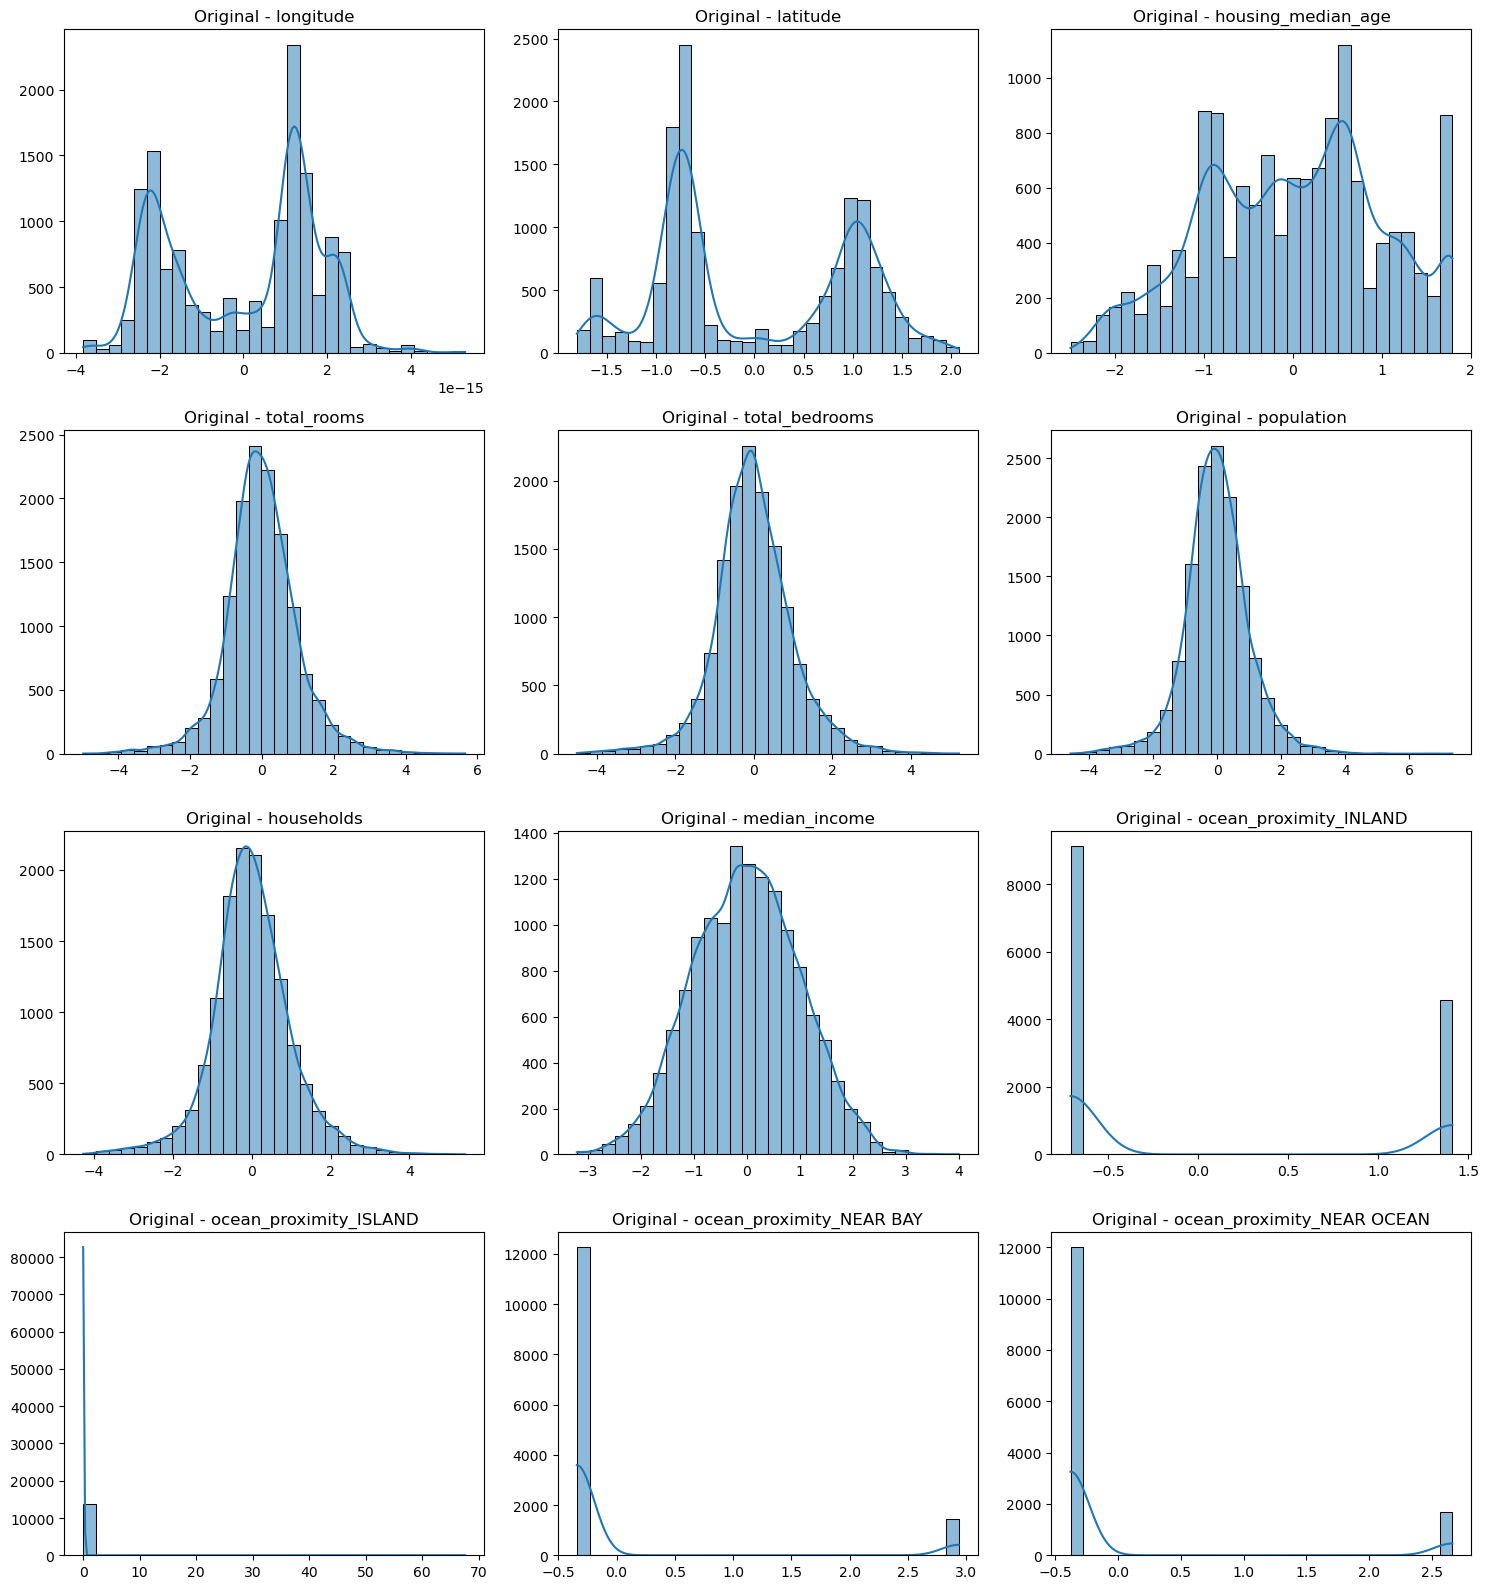

In [91]:
plot_all_histograms(X_train_transformed_df,title_prefix='Original -')

In [92]:
positive = [col for col in X_train.columns if (X_train[col] > 0).all()]

In [93]:
positive

['latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

In [94]:
boxcox_cols = ['latitude',
 'housing_median_age',
 'total_rooms',
 'total_bedrooms',
 'population',
 'households',
 'median_income']

In [95]:
from scipy.stats import boxcox

In [96]:
boxcox(y_train)

(array([80.09145777, 71.80757325, 66.00535957, ..., 58.94737101,
        82.01614618, 78.40112308]),
 np.float64(0.2530901601217281))

In [97]:
pt_bc = PowerTransformer(method='box-cox')

In [99]:
X_train_bc = pt_bc.fit_transform(X_train[boxcox_cols])

In [100]:
X_train_bc_df = pd.DataFrame(X_train_bc,columns=boxcox_cols)

In [101]:
# iki yontemin karsilastirilmasi 

In [102]:
col = 'median_income'

print(f"Orijinal Skew: {X_train[col].skew():.4f}")
print(f"Yeo-Johnson Skew: {X_train_transformed_df[col].skew():.4f}")
print(f"Box-Cox Skew: {X_train_bc_df[col].skew():.4f}")

Orijinal Skew: 0.9008
Yeo-Johnson Skew: -0.0009
Box-Cox Skew: -0.0028


In [103]:
# iki yontemin grafik cizimi 

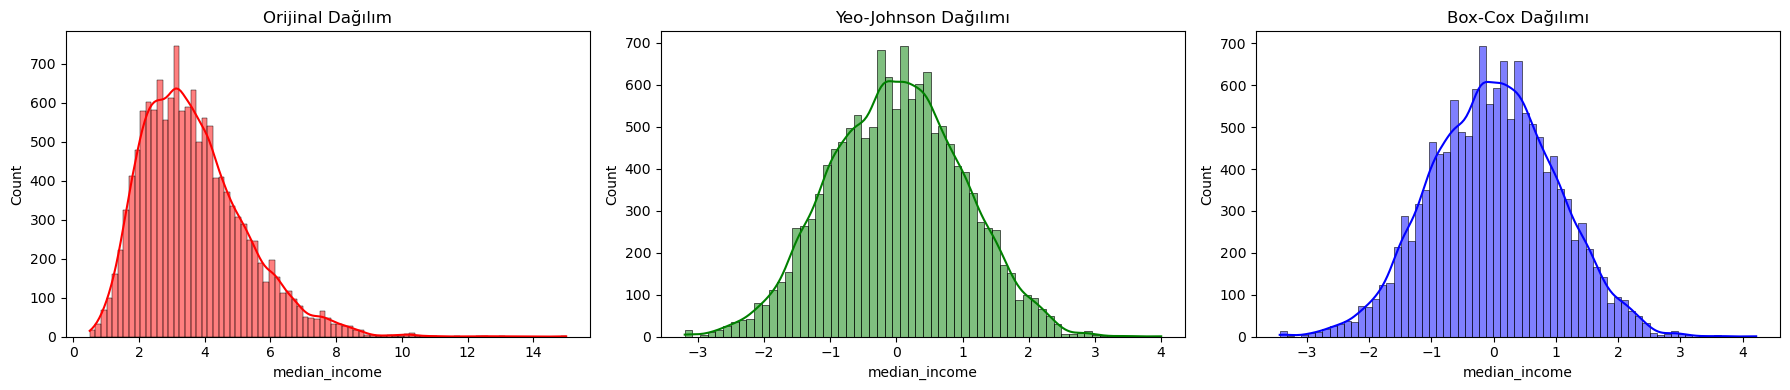

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Orijinal
sns.histplot(X_train['median_income'], kde=True, ax=axes[0], color='red')
axes[0].set_title("Orijinal Dağılım")

# 2. Yeo-Johnson
sns.histplot(X_train_transformed_df['median_income'], kde=True, ax=axes[1], color='green')
axes[1].set_title("Yeo-Johnson Dağılımı")

# 3. Box-Cox
sns.histplot(X_train_bc_df['median_income'], kde=True, ax=axes[2], color='blue')
axes[2].set_title("Box-Cox Dağılımı")

plt.tight_layout()
plt.show()